<a href="https://colab.research.google.com/github/yamatai-wizard/GCI_Competition2/blob/main/NFL_Draft_Prediction_ipynb%E3%80%80%E5%AE%9F%E8%A1%8C%E7%89%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 第2回データ分析コンペティション：NFL Draft Prediction

## 目次
1. セットアップ
2. データ読み込み
3. データの分析・EDA
4. 前処理
5. ベースラインモデル
6. 仮説と特徴量エンジニアリング
7. 提出ファイル作成
8. 今後の展望

## 1. セットアップ

In [25]:
from google.colab import drive,files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, auc

from xgboost import XGBClassifier

!pip install optuna
import optuna
from optuna.samplers import TPESampler

In [27]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 2. データ読み込み

In [28]:
PATH = '/content/drive/MyDrive/GCI/NFL Draft Prediction/'

train = pd.read_csv(PATH + 'train.csv')
test = pd.read_csv(PATH + 'test.csv')

## 4. 前処理

In [29]:
# 使わない列の削除
train = train.drop(columns=["Id"])
test = test.drop(columns=["Id"])

In [30]:
train.isnull().sum()

,0
Year,0
Age,435
School,0
Height,0
Weight,0
Sprint_40yd,145
Vertical_Jump,554
Bench_Press_Reps,721
Broad_Jump,581
Agility_3cone,970


In [31]:
test.isnull().sum()

,0
Year,0
Age,115
School,0
Height,0
Weight,0
Sprint_40yd,29
Vertical_Jump,143
Bench_Press_Reps,184
Broad_Jump,147
Agility_3cone,247


In [32]:
# # カテゴリデータをラベルエンコーディング
# label_encoders = {}
# for c in ["Player_Type", "Position_Type", "Position"]:
#     label_encoders[c] = LabelEncoder()
#     train[c] = label_encoders[c].fit_transform(train[c].astype(str))
#     test[c] = label_encoders[c].transform(test[c].astype(str))

In [33]:
# prompt: カテゴリデータをワンホットエンコーディングして.0,1で

import pandas as pd
# カテゴリデータのワンホットエンコーディング
train = pd.get_dummies(train, columns=["Player_Type", "Position_Type", "Position"], dummy_na=False, dtype=int)
test = pd.get_dummies(test, columns=["Player_Type", "Position_Type", "Position"], dummy_na=False, dtype=int)

# trainとtestでカラムを揃える
train_cols = set(train.columns)
test_cols = set(test.columns)

missing_in_test = list(train_cols - test_cols)
for c in missing_in_test:
    if c != 'Drafted': # 'Drafted' はtestには存在しない
        test[c] = 0.0

missing_in_train = list(test_cols - train_cols)
for c in missing_in_train:
    train[c] = 0.0

# カラムの順序をtrainに合わせる
test = test[train.columns.drop('Drafted')]

In [34]:
train.head()

,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Drafted,Player_Type_defense,Player_Type_offense,Player_Type_special_teams,Position_Type_backs_receivers,Position_Type_defensive_back,Position_Type_defensive_lineman,Position_Type_kicking_specialist,Position_Type_line_backer,Position_Type_offensive_lineman,Position_Type_other_special,Position_C,Position_CB,Position_DB,Position_DE,Position_DT,Position_FB,Position_FS,Position_ILB,Position_K,Position_LS,Position_OG,Position_OLB,Position_OT,Position_P,Position_QB,Position_RB,Position_S,Position_SS,Position_TE,Position_WR
0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,1.0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,1.0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,1.0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,1.0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,1.0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


## 6. 仮説と特徴量エンジニアリング

In [35]:
for df in [train, test]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

In [36]:
import numpy as np
# School列をターゲットエンコーディング (リーク防止)
# Cross-validationを用いてターゲットエンコーディングを行う
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train['School_encoded'] = 0
for fold, (train_idx, val_idx) in enumerate(kf.split(train.drop('Drafted', axis=1), train['Drafted'])):
    X_train_fold, X_val_fold = train.iloc[train_idx], train.iloc[val_idx]
    # 訓練データでのターゲットエンコーディングの平均値を計算
    school_mean = X_train_fold.groupby('School')['Drafted'].mean()
    # 検証データに適用
    train.loc[val_idx, 'School_encoded'] = X_val_fold['School'].map(school_mean).fillna(school_mean.mean())

# School_encodedが0または1の場合は欠損値にする
train.loc[train['School_encoded'].isin([0, 1]), 'School_encoded'] = np.nan


# テストデータに対するターゲットエンコーディング
# 訓練データ全体の平均値を使用
school_mean_overall = train.groupby('School')['Drafted'].mean()
test['School_encoded'] = test['School'].map(school_mean_overall).fillna(school_mean_overall.mean())

# School_encodedが0または1の場合は欠損値にする
test.loc[test['School_encoded'].isin([0, 1]), 'School_encoded'] = np.nan

# 元のSchool列は削除
train = train.drop(columns=['School'])
test = test.drop(columns=['School'])

/tmp/ipython-input-36-3705972094.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.33333333 0.5        0.64285714 0.5905546  0.76744186 0.66101695
 0.61290323 0.70967742 0.33333333 0.63157895 0.         0.52380952
 0.72727273 0.71111111 0.71428571 0.61290323 0.75       0.68571429
 0.64285714 0.59375    0.         0.65909091 0.77272727 0.69230769
 0.55555556 1.         0.66037736 0.61538462 0.69230769 0.61290323
 0.76744186 0.66666667 0.68421053 0.7        0.72972973 0.53571429
 0.80487805 0.7        0.68571429 0.61290323 0.74074074 0.66666667
 0.625      0.7        0.68965517 0.63636364 0.72727273 0.64705882
 0.66666667 0.42857143 0.         0.78723404 0.75       0.5905546
 0.65789474 0.5905546  0.72727273 0.68965517 0.64285714 0.
 0.52941176 0.75       0.27272727 0.76744186 0.58333333 0.78723404
 0.59090909 0.5905546  0.59375    0.61290323 0.68571429 0.42857143
 0.74074074 0.66101695 0.53846154 0.

In [37]:
X = train.drop(columns=['Drafted'])
y = train['Drafted']

sampler = TPESampler(seed=42)

# Define objective function specifically for XGBoost
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 1),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
    }
    model = XGBClassifier(**params, random_state=42,
                          use_label_encoder=False,
                          eval_metric='logloss',
                          verbosity=0)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_valid)[:, 1]
        auc_value = roc_auc_score(y_valid, y_pred_proba)
        auc_scores.append(auc_value)

    return np.mean(auc_scores)

# Optimize only XGBoost
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=50, n_jobs=1)

best_params = study.best_params
print(f"XGBoost best params: {best_params}")
print(f"Best AUC: {study.best_value:.4f}\n")

# Build optimized XGBoost model
optimized_model = XGBClassifier(**best_params, random_state=42,
                                use_label_encoder=False,
                                eval_metric='logloss',
                                verbosity=0)

# Evaluate using stratified k-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('\n=== XGBoost Evaluation ===')
auc_scores = []
test_pred_proba_list = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f'Fold{fold+1}')

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    optimized_model.fit(X_train, y_train)

    y_valid_pred_proba = optimized_model.predict_proba(X_valid)[:,1]
    auc_value = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc_value)
    print(f'AUC:{round(auc_value,4)}')

    test_pred_proba = optimized_model.predict_proba(test)[:,1]
    test_pred_proba_list.append(test_pred_proba)

mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))
test_pred_proba_mean = np.mean(test_pred_proba_list, axis=0)

[I 2025-07-03 02:51:05,643] A new study created in memory with name: no-name-d97a84cc-c559-4f9b-9b58-aedb455c34b0
[I 2025-07-03 02:51:19,560] Trial 0 finished with value: 0.8169413079884983 and parameters: {'n_estimators': 218, 'max_depth': 15, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.15599452033620265, 'min_child_weight': 1}. Best is trial 0 with value: 0.8169413079884983.
[I 2025-07-03 02:51:21,998] Trial 1 finished with value: 0.8120833188378697 and parameters: {'n_estimators': 440, 'max_depth': 10, 'learning_rate': 0.11114989443094977, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'gamma': 0.8324426408004217, 'min_child_weight': 3}. Best is trial 0 with value: 0.8169413079884983.
[I 2025-07-03 02:51:22,790] Trial 2 finished with value: 0.8346530903362126 and parameters: {'n_estimators': 132, 'max_depth': 5, 'learning_rate': 0.028145092716060652, 'subsample': 0.762378215816119,

XGBoost best params: {'n_estimators': 252, 'max_depth': 10, 'learning_rate': 0.01206616928592265, 'subsample': 0.5011168762119151, 'colsample_bytree': 0.5530804883755938, 'gamma': 0.014197437064483384, 'min_child_weight': 10}
Best AUC: 0.8383


=== XGBoost Evaluation ===
Fold1
AUC:0.8132
Fold2
AUC:0.8604
Fold3
AUC:0.8684
Fold4
AUC:0.7971
Fold5
AUC:0.8522

Average Validation AUC: 0.8383


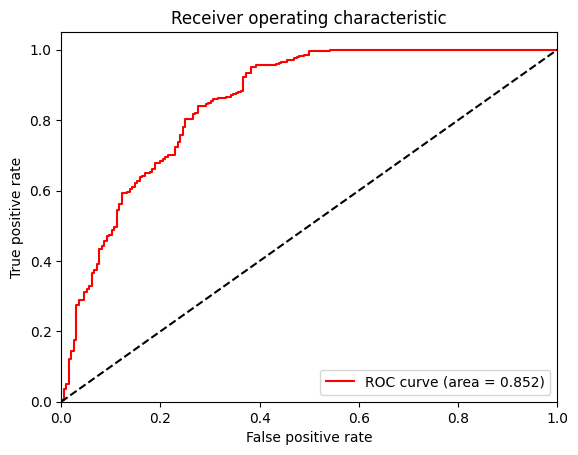

In [38]:
# 偽陽性率と真陽性率の算出
fpr, tpr, thresholds = roc_curve(y_valid, y_valid_pred_proba)

# AUCの算出
auc_value = auc(fpr, tpr)

# ROC曲線の描画
plt.plot(fpr, tpr, color='red', label='ROC curve (area = %.3f)' % auc_value)
plt.plot([0, 1], [0, 1], color='black', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="best")


=== Feature Importances ===
                             Feature  Importance
1                                Age    0.308150
12         Player_Type_special_teams    0.087790
32                       Position_OT    0.035398
4                        Sprint_40yd    0.033371
34                       Position_QB    0.032651
39                       Position_WR    0.031418
38                       Position_TE    0.030415
31                      Position_OLB    0.028977
13     Position_Type_backs_receivers    0.028031
2                             Height    0.027924
15   Position_Type_defensive_lineman    0.027295
40                               BMI    0.024734
6                   Bench_Press_Reps    0.024682
9                            Shuttle    0.024026
3                             Weight    0.024018
35                       Position_RB    0.023791
41                    School_encoded    0.023437
10               Player_Type_defense    0.021875
21                       Position_CB    

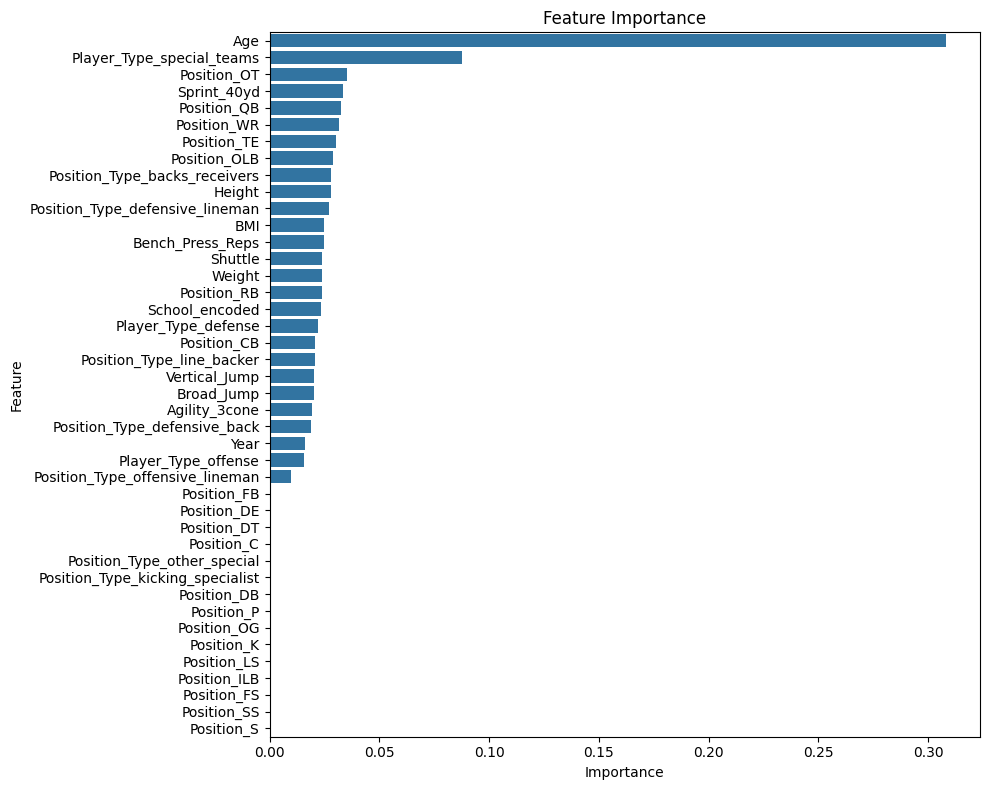

In [39]:
# 特徴量重要度を取得
feature_importances = optimized_model.feature_importances_

# 特徴量名と重要度を組み合わせる
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})

# 重要度で降順にソート
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 結果を表示
print("\n=== Feature Importances ===")
print(importance_df)

# 特徴量重要度を可視化 (オプション)
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

## 7. 提出ファイル作成

In [37]:
submission = pd.read_csv(PATH + 'sample_submission.csv')
submission["Drafted"] = test_pred_proba_mean
submission.to_csv(PATH + 'submission.csv', index=False)

files.download(PATH + 'submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. 今後の展望

　本ノートブックでは、データの前処理から特徴量エンジニアリング、モデル構築、評価まで、ベースラインモデルの構築を行いました。

　今後はこのベースラインを土台として、さらに高度な特徴量の工夫やアルゴリズムの改善などによって精度向上を目指していくことができます。例えば、以下のような工夫が考えられます。

- カテゴリデータのエンコーディング手法の変更
- 欠損値の補完手法の変更
- 別のモデルの検討
- モデルのハイパーパラメータ調整
- 特徴量エンジニアリング


　高スコア獲得を目指して、頑張りましょう！